<a href="https://colab.research.google.com/github/Catherine-23-Codes/CART_SC3_PS3/blob/main/Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving TRAIN.zip to TRAIN.zip


In [3]:
import os
os.listdir()

['.config', 'TRAIN.zip', 'sample_data']

In [4]:
import zipfile

zip_ref = zipfile.ZipFile("TRAIN.zip", 'r')
zip_ref.extractall("/content/dataset")
zip_ref.close()

In [5]:
import os
os.listdir("/content/dataset")

['TRAIN']

In [6]:
import os
os.listdir("/content/dataset/TRAIN")

['A', 'B']

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/TRAIN",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    "/content/dataset/TRAIN",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 27 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6667 - loss: 0.6822 - val_accuracy: 0.5000 - val_loss: 6.1863
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6296 - loss: 3.0219 - val_accuracy: 0.5000 - val_loss: 15.9518
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 15.0066 - val_accuracy: 0.5000 - val_loss: 9.7183
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 8.0418 - val_accuracy: 0.5000 - val_loss: 2.0560
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9259 - loss: 0.2685 - val_accuracy: 0.5000 - val_loss: 5.4443
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6296 - loss: 1.9873 - val_accuracy: 0.5000 - val_loss: 6.2628
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 2.1386 - val_accuracy: 0.8333 - val_loss: 4.1560
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9259 - loss: 0.3689 - val_accuracy: 0.6667 - val_loss: 3.8089
Epoch 9/10
1/1 ━━━━━━━━━━

In [12]:
from google.colab import files
uploaded = files.upload()

Saving O_990.jpg to O_990.jpg


In [14]:
from google.colab import files
uploaded = files.upload()

Saving O_13760.jpg to O_13760.jpg


In [15]:
import os
os.listdir()

['.config', 'O_990.jpg', 'dataset', 'TRAIN.zip', 'O_13760.jpg', 'sample_data']

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("O_990.jpg", target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Class B")
else:
    print("Class A")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Class B


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

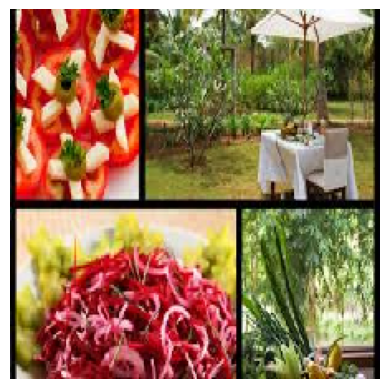

In [18]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

In [19]:
import os
os.listdir()

['.config', 'O_990.jpg', 'dataset', 'TRAIN.zip', 'O_13760.jpg', 'sample_data']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


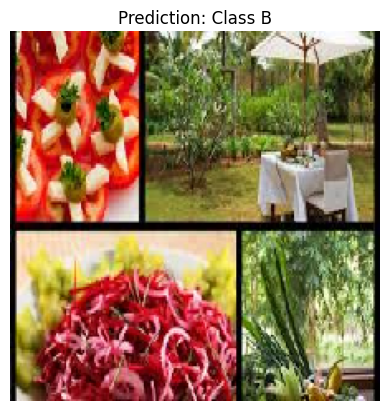

In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img("O_990.jpg", target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

label = "Class B" if prediction > 0.5 else "Class A"

plt.imshow(img)
plt.title("Prediction: " + label)
plt.axis("off")
plt.show()